In [1]:
%matplotlib inline 
# the line above is a command that configures Matplotlib to render plot images directly inside the Jupyter Notebook, beneath the code cell that generated them.
# we will need to have "scikit-learn" package installed in our local environment, after activating the environment (such as funtimes)
# example (Mac): 
#    conda activate funtimes
#    conda install scikit-learn -y
# more instructions if needed: https://scikit-learn.org/stable/install.html

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

# Linear model and basic functions from scikit-learn
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Specific models we will use beyond linear regression from scikit-learn
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import RadiusNeighborsRegressor

# Ordinary Least Squares Linear Regression

In [2]:
# This example is from the diabetes dataset in scikit-learn
# https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
# Load the diabetes dataset
# Load the full dataset object
diabetes = datasets.load_diabetes()

# Look at just the feature names
print(diabetes.feature_names)

# Look at the full description (dataset background, source, feature explanations)
print(diabetes.DESCR)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, bloo

In [3]:
# List all public classes and functions in linear_model from scikit-learn
options = [item for item in dir(linear_model) if not item.startswith("_")]
print(options)

['ARDRegression', 'BayesianRidge', 'ElasticNet', 'ElasticNetCV', 'GammaRegressor', 'HuberRegressor', 'Lars', 'LarsCV', 'Lasso', 'LassoCV', 'LassoLars', 'LassoLarsCV', 'LassoLarsIC', 'LinearRegression', 'LogisticRegression', 'LogisticRegressionCV', 'MultiTaskElasticNet', 'MultiTaskElasticNetCV', 'MultiTaskLasso', 'MultiTaskLassoCV', 'OrthogonalMatchingPursuit', 'OrthogonalMatchingPursuitCV', 'PassiveAggressiveClassifier', 'PassiveAggressiveRegressor', 'Perceptron', 'PoissonRegressor', 'QuantileRegressor', 'RANSACRegressor', 'Ridge', 'RidgeCV', 'RidgeClassifier', 'RidgeClassifierCV', 'SGDClassifier', 'SGDOneClassSVM', 'SGDRegressor', 'TheilSenRegressor', 'TweedieRegressor', 'enet_path', 'lars_path', 'lars_path_gram', 'lasso_path', 'orthogonal_mp', 'orthogonal_mp_gram', 'ridge_regression']


(442, 10) (442,)
y = 735.25 * x + 152.50
Mean squared error: 4787.86
Coefficient of determination (R-squared): 0.12


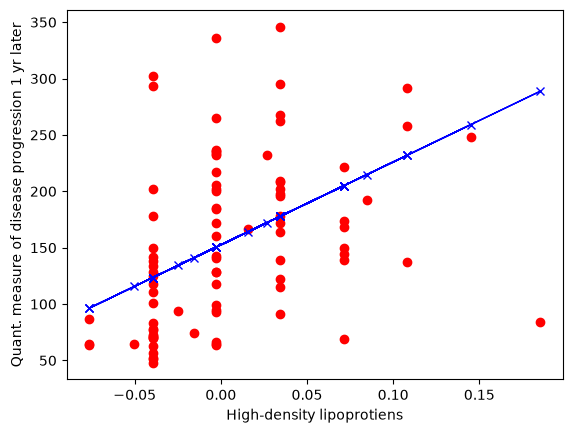

In [5]:
# Example 1
# Load the diabetes dataset so that we can more quickly run a regression
X, y = datasets.load_diabetes(return_X_y=True)
print(X.shape,y.shape)

# Use only one feature 
# Select a single feature (column index 7) and reshape it into a 2D array of shape (442, 1).
# from above we know 7 is "s3     hdl, high-density lipoproteins"
X = X[:, np.newaxis, 7]

# Split the data into training/testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)
# This separates the data into two sets:
# Training set (80% / 353 samples): Used to train the model.
# Testing set (20% / 89 samples): Reserved to evaluate how well the model generalizes to new data.
# random_state=4: A seed number that ensures the random split is reproducible every time you run the code.

# Create linear regression object
regr = linear_model.LinearRegression()
# The "linear_model.LinearRegression" uses an ordinary least squares
# minimizes the sum of squared residuals between predictions and actual values
# If you wanted a different optimization method (like Ridge, Lasso, or ElasticNet), 
# you would instantiate a different class (e.g., linear_model.Ridge())

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Evaluate model performance:
# The coefficients of the line y_pred = m * X_test + b
print('y = %.2f * x + %.2f' % (regr.coef_[0], regr.intercept_))
# The mean squared error (lower numbers, better accuracy)
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination (R-squared): %.2f'
      % r2_score(y_test, y_pred))

# Plot outputs
plt.scatter(X_test, y_test,  color='red')
plt.plot(X_test, y_pred,  '-x', color='blue', linewidth=1)
plt.xlabel('High-density lipoprotiens')
plt.ylabel('Quant. measure of disease progression 1 yr later')
plt.show()

In [6]:
# Example 2
##### What is different in this chunk of code below from the example above?
# Load the diabetes dataset
X, y = datasets.load_diabetes(return_X_y=True)

# Split the data into training/testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Evaluate model performance:
# The coefficients of the line y_pred = m * X_test + b
print('y = %.2f * x + %.2f' % (regr.coef_[0], regr.intercept_))
# The mean squared error (lower numbers, better accuracy)
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination (R-squared): %.2f'
      % r2_score(y_test, y_pred))

y = 33.41 * x + 151.15
Mean squared error: 2939.36
Coefficient of determination (R-squared): 0.46


# K-Nearest-Neighbors (KNN) Regression

## Linear K-Nearest-Neighbors Regression

Choose a number for k:  2


R-squared score: 1.00


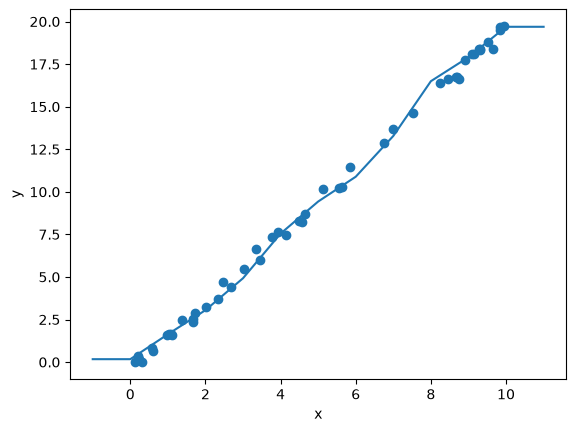

In [8]:
# Choose the number of neighbors = 'k'
k  = int(input('Choose a number for k: '))

# Generate some mostly linear data with stochastic noise added
# This line generates a pandas DataFrame 'x' containing 50 random numbers between 0 and 10 to serve as the input feature.
x = pd.DataFrame([10 * random.random() for __ in range(50)])
# This line creates the target variable 'y' using a linear equation (2 * x - 1) and adds random noise between 0 and 1 to simulate real-world variance.
y = 2 * x - 1 + pd.DataFrame([random.random() for __ in range(50)])

# Initiate the KNN regression model, setting its 'k' parameter (number of neighbors) to 'k' that we chose above.
model = KNeighborsRegressor(n_neighbors=k)
model.fit(x, y)

# compute the R-squared score
print("R-squared score: {0:.2f}".format(model.score(x,y)))

# plot the model together with the data
xfit = pd.DataFrame([i for i in range(-1, 12)])
yfit = model.predict(xfit)
plt.scatter(x, y)
plt.plot(xfit, yfit)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Non-linear K-Nearest-Neighbors Regression

Choose a number for k:  8


R-squared score: 0.79


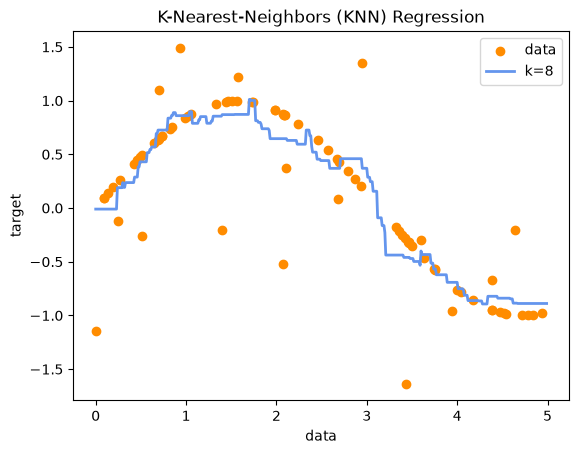

In [11]:
k  = int(input('Choose a number for k: '))

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

# Fit regression model
regr_1 = KNeighborsRegressor(n_neighbors=k)
regr_1.fit(X, y)
print("R-squared score: {0:.2f}".format(regr_1.score(X,y)))

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="k="+str(k), linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("K-Nearest-Neighbors (KNN) Regression")
plt.legend()
plt.show()

# Multi-Layer Perceptron (MLP) Regression

## Linear Multi-Layer Perceptron (MLP) Regression

In [ ]:
n  = int(input('Choose a number for hidden nodes: '))

X = pd.DataFrame([10 * random.random() for __ in range(50)])
y = 2 * X - 1 + pd.DataFrame([random.random() for __ in range(50)])
y = y.squeeze() # flattens y to pass it into the model's .fit() function:

# pick model
model = MLPRegressor(hidden_layer_sizes=(n,),
                     activation='relu', max_iter=10000)
model.fit(X, y) 

# compute the R-squared score
print("R-squared score: {0:.2f}".format(model.score(X,y)))

# plot the model together with the data
Xfit = pd.DataFrame([i for i in range(-1, 12)])
yfit = model.predict(Xfit)
plt.scatter(X, y)
plt.plot(Xfit, yfit)
plt.show()


## Non-linear Multi-Layer Perceptron (MLP) Regression

In [ ]:
# Choose a number of hidden nodes...
n  = int(input('Choose a number for hidden nodes: '))

# Import the necessary modules and libraries
import numpy as np
import matplotlib.pyplot as plt

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

# Fit regression model
regr_1 = MLPRegressor(hidden_layer_sizes=(n,n), activation='tanh', max_iter=10000)
regr_1.fit(X, y)
print("R-squared score: {}".format(regr_1.score(X,y)))

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="hidden nodes="+str(n), linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("MLP Regression")
plt.legend()
plt.show()

# Radius Neighbors Regression

## Linear Radius Neighbors Regression

In [ ]:
r  = float(input('Choose a number for radius: '))

# generate some mostly linear data with stochastic noise added
x = pd.DataFrame([10 * random.random() for __ in range(50)])
y = 2 * x - 1 + pd.DataFrame([random.random() for __ in range(50)])

# pick model
model = RadiusNeighborsRegressor(radius=r)
model.fit(x, y)

# compute the R-squared score
print("R-squared score: {0:.2f}".format(model.score(x,y)))

# plot the model together with the data
xfit = pd.DataFrame([i for i in range(-1, 12)])
yfit = model.predict(xfit)
plt.scatter(x, y)
plt.plot(xfit, yfit)
plt.show()

## Non-linear Radius Neighbors Regression

In [ ]:
r  = float(input('Choose a number for radius (can be a decimal < 1.0): '))

# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

# Fit regression model
regr_1 = RadiusNeighborsRegressor(radius=r)
regr_1.fit(X, y)
print("R-squared score: {0:.2f}".format(regr_1.score(X,y)))

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="radius="+str(r), linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("KNN Regression")
plt.legend()
plt.show()